# Transformers from scratch · Part 2: a tiny GPT trained on Shakespeare

This is how every GPT is trained, at miniature scale: take a pile of text and train a Transformer to **predict the next token**. GPT-3, Llama and the base models behind ChatGPT were trained the same way, on trillions of tokens instead of one million characters.

| | |
|---|---|
| **Task** | predict the next character of a text |
| **Data** | Tiny Shakespeare: 1.1 million characters of Shakespeare's plays |
| **Model** | a 6-layer GPT with 10.8 million parameters: the *decoder* half of Part 1's Transformer, without cross-attention |
| **Metric** | validation loss (cross-entropy per character), compared with simple baselines, plus text samples you can read |

**Steps**

1. Data
2. Tokens: one token per character
3. Batches: the next-token objective
4. The model: embeddings → causal self-attention → MLP → pre-norm block → GPT
5. Training: AdamW, warm-up + cosine schedule, mixed precision
6. Generating text: greedy decoding, sampling, temperature, top-k
7. Measuring: how good is the loss, compared with simple baselines?
8. Looking inside: attention maps

**What's new compared with Part 1:** there is no encoder and no source sentence. The model reads text and continues it, and the same causal self-attention does all the work. The settings follow the Shakespeare example of Andrej Karpathy's nanoGPT; training takes a few minutes on an RTX 4090.

In [1]:
# Settings (as in nanoGPT's "shakespeare_char" example)
BLOCK_SIZE = 256     # context length: how many characters the model sees at once
BATCH_SIZE = 64      # sequences per training step
N_LAYERS = 6         # Transformer blocks
N_HEADS = 6          # attention heads per block
D_MODEL = 384        # size of every token vector
DROPOUT = 0.2
MAX_STEPS = 5000     # training steps
LR = 1e-3            # peak learning rate
WARMUP = 100         # warm-up steps
EVAL_EVERY = 250     # how often to measure train / validation loss

## 0 · Setup

Two speed settings for NVIDIA GPUs: **TF32** lets float32 matrix multiplications use the tensor cores, and **bf16 autocast** runs the big matrix multiplications in 16-bit floats during training. Both are standard in LLM training; on a Mac or a CPU they're simply skipped.

In [2]:
import contextlib, math, time, urllib.request
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
torch.manual_seed(0)
torch.backends.cuda.matmul.allow_tf32 = True
autocast = (lambda: torch.autocast("cuda", dtype=torch.bfloat16)) if device == "cuda" else contextlib.nullcontext
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.14.1 | device: mps


## 1 · Data

In [3]:
path = Path("data/tinyshakespeare.txt")
if not path.exists():
    path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt", path)
text = path.read_text(encoding="utf-8")
print(f"{len(text):,} characters\n")
print(text[:500])

1,115,394 characters

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 2 · Tokens: one token per character

The simplest possible tokenizer: every distinct character is a token. The vocabulary is tiny (65 characters) and nothing is ever unknown. The price is long sequences, one token per character. GPT-2 uses about 50,000 *subword* tokens instead, so one token covers about 4 characters of English (Part 3).

In [4]:
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}          # character -> id
itos = {i: c for i, c in enumerate(chars)}          # id -> character
encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: "".join(itos[i] for i in ids)

print(f"{vocab_size} tokens:", repr("".join(chars)))
print(encode("To be, or not to be"))
print(decode(encode("To be, or not to be")))

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]           # first 90% for training, last 10% for validation
print(f"\ntrain {len(train_data):,} tokens | validation {len(val_data):,} tokens")

65 tokens: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
[32, 53, 1, 40, 43, 6, 1, 53, 56, 1, 52, 53, 58, 1, 58, 53, 1, 40, 43]
To be, or not to be

train 1,003,854 tokens | validation 111,540 tokens


## 3 · Batches: the next-token objective

A training example is a window of `BLOCK_SIZE` characters `x`, and the same window shifted one character to the right, `y`. At every position $t$ the model must predict `y[t]` (the next character) from `x[0..t]` (everything up to and including position $t$). So one window of 256 characters holds 256 training examples at once: predict character 2 from character 1, character 3 from characters 1–2, and so on. The causal mask makes this possible in one forward pass, exactly as in Part 1's decoder.

In [5]:
def get_batch(split, batch_size=BATCH_SIZE):
    source = train_data if split == "train" else val_data
    starts = torch.randint(len(source) - BLOCK_SIZE - 1, (batch_size,))           # random window positions
    x = torch.stack([source[s : s + BLOCK_SIZE] for s in starts])                 # (B, T)
    y = torch.stack([source[s + 1 : s + BLOCK_SIZE + 1] for s in starts])         # (B, T): shifted by one
    return x.to(device), y.to(device)

x, y = get_batch("train")
print("x", tuple(x.shape), "| y", tuple(y.shape), "\n")
for t in range(8):
    print(f"context {decode(x[0, : t + 1].tolist())!r:<12} -> next character {decode([y[0, t].item()])!r}")

x (64, 256) | y (64, 256) 

context 'm'          -> next character 'e'
context 'me'         -> next character '.'
context 'me.'        -> next character '\n'
context 'me.\n'      -> next character '\n'
context 'me.\n\n'    -> next character 'W'
context 'me.\n\nW'   -> next character 'A'
context 'me.\n\nWA'  -> next character 'R'
context 'me.\n\nWAR' -> next character 'W'


## 4 · The model

```
 character ids (B, T)
        │
 token embedding + position embedding
        │
 ┌──────▼──────────────────────────┐
 │ BLOCK  (× N)                    │
 │  x = x + attention(LayerNorm(x)) │   causal self-attention: look at earlier characters
 │  x = x + MLP(LayerNorm(x))       │   process each position on its own
 └──────┬──────────────────────────┘
        │
 LayerNorm → linear → a score for each of the 65 characters
```

### 4.1 Embeddings

As in Part 1, a lookup table turns each character id into a vector of size `D_MODEL`. GPTs **learn** the position vectors too (one learned vector per position, up to `BLOCK_SIZE`) instead of using the fixed sinusoids from Part 1. Both work about equally well; the paper found the same.

### 4.2 Causal self-attention

This is Part 1's multi-head attention with the **causal mask** always on: position $t$ may only look at positions $0 \dots t$. Queries, keys and values all come from the same text. One addition: dropout on the attention weights, which randomly hides some of the connections during training.

In [6]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout):
        super().__init__()
        self.h, self.d_k = n_heads, d_model // n_heads
        self.w_q, self.w_k, self.w_v = nn.Linear(d_model, d_model), nn.Linear(d_model, d_model), nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.attn_dropout, self.out_dropout = nn.Dropout(dropout), nn.Dropout(dropout)
        self.register_buffer("causal", torch.tril(torch.ones(block_size, block_size, dtype=torch.bool)))
        self.weights = None                                                 # kept for plotting

    def forward(self, x):                                                   # x: (B, T, d_model)
        B, T, _ = x.shape
        split = lambda t: t.view(B, T, self.h, self.d_k).transpose(1, 2)    # (B, T, d_model) -> (B, h, T, d_k)
        q, k, v = split(self.w_q(x)), split(self.w_k(x)), split(self.w_v(x))
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_k)              # (B, h, T, T)
        scores = scores.masked_fill(~self.causal[:T, :T], float("-inf"))    # no looking ahead
        weights = scores.softmax(dim=-1)
        self.weights = weights.detach()
        out = self.attn_dropout(weights) @ v                                # (B, h, T, d_k)
        out = out.transpose(1, 2).reshape(B, T, self.h * self.d_k)          # concatenate the heads
        return self.out_dropout(self.w_o(out))

### 4.3 The MLP

The feed-forward network from Part 1, under its GPT name: Linear → GELU → Linear, widening to 4 × `D_MODEL` in between. **GELU** is a smooth version of ReLU (negative inputs are squashed gently instead of cut to zero); GPT-2 and most LLMs since use it.

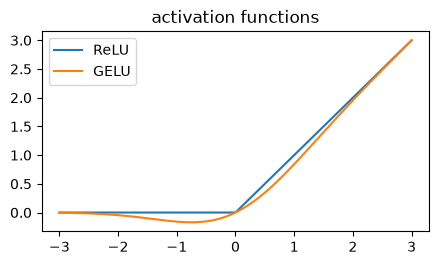

In [7]:
class MLP(nn.Module):
    def __init__(self, d_model, dropout):
        super().__init__()
        self.fc = nn.Linear(d_model, 4 * d_model)
        self.proj = nn.Linear(4 * d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.proj(F.gelu(self.fc(x))))

xs = torch.linspace(-3, 3, 200)
plt.figure(figsize=(5, 2.6))
plt.plot(xs, F.relu(xs), label="ReLU"); plt.plot(xs, F.gelu(xs), label="GELU")
plt.legend(); plt.title("activation functions"); plt.show()

### 4.4 The block: pre-norm residual connections

Part 1 used the paper's **post-norm** arrangement: `x = LayerNorm(x + sublayer(x))`. GPT-2 and nearly every LLM since use **pre-norm**:

$$x \leftarrow x + \text{Attention}(\text{LayerNorm}(x)), \qquad x \leftarrow x + \text{MLP}(\text{LayerNorm}(x))$$

The LayerNorm moves inside the branch, so the residual path ($x + \dots$) runs untouched from the input to the output of the whole network. Deep stacks train more stably that way, and a final LayerNorm after the last block cleans up the result.

In [8]:
class Block(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.mlp = MLP(d_model, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))     # tokens exchange information
        x = x + self.mlp(self.ln2(x))      # each token is processed on its own
        return x

### 4.5 The GPT

Embeddings → `N_LAYERS` blocks → final LayerNorm → a linear layer that gives a score (logit) for every character. Two details from GPT-2:

- **Weight tying**: the output layer reuses the token-embedding matrix, as in the Transformer paper. The score for character $c$ is the dot product of the final vector with $c$'s own embedding.
- **Initialisation**: weights start as small random numbers ($\mathcal{N}(0, 0.02)$), and the last projection of each residual branch is scaled down by a further $1/\sqrt{2N}$. Each block then starts close to "do nothing", and the stack begins as a near-identity function that training gradually shapes.

When `targets` are given, the model also returns the loss: the cross-entropy of the next-character predictions, as in Part 1.

In [9]:
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, block_size, dropout):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)          # learned positions
        self.dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, block_size, dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight                     # weight tying
        for name, p in self.named_parameters():
            if p.dim() >= 2:
                std = 0.02 / math.sqrt(2 * n_layers) if name.endswith(("w_o.weight", "proj.weight")) else 0.02
                nn.init.normal_(p, mean=0.0, std=std)
            elif name.endswith("bias"):
                nn.init.zeros_(p)

    def forward(self, idx, targets=None):                          # idx: (B, T) character ids
        B, T = idx.shape
        x = self.dropout(self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device)))
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.ln_f(x))                           # (B, T, vocab_size)
        loss = None if targets is None else F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

model = GPT(vocab_size, D_MODEL, N_HEADS, N_LAYERS, BLOCK_SIZE, DROPOUT).to(device)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.1f}M parameters")

logits, loss = model(x, y)
print("input", tuple(x.shape), "-> logits", tuple(logits.shape))
print(f"untrained loss {loss.item():.2f} vs ln({vocab_size}) = {math.log(vocab_size):.2f} (uniform guessing)")

10.8M parameters
input (64, 256) -> logits (64, 256, 65)
untrained loss 4.18 vs ln(65) = 4.17 (uniform guessing)


## 5 · Training

The recipe used for essentially every LLM:

- **Objective**: cross-entropy of the next token, averaged over every position of every sequence in the batch.
- **AdamW**: Adam with *weight decay* (each step shrinks the weights slightly toward zero, which discourages memorising). Only weight matrices are decayed, not biases or LayerNorm parameters.
- **Learning-rate schedule**: a short linear **warm-up** (`WARMUP` steps), then a **cosine decay** down to a tenth of the peak. Big steps early, when there's a lot to learn; small steps at the end, to settle into a good minimum.
- **Gradient clipping** at norm 1.0, so one unusual batch can't produce a huge update.
- **Mixed precision** (bf16) on NVIDIA GPUs, for speed.

Every `EVAL_EVERY` steps we estimate the loss on both splits, averaged over 50 random batches, with dropout off.

In [ ]:
model = GPT(vocab_size, D_MODEL, N_HEADS, N_LAYERS, BLOCK_SIZE, DROPOUT).to(device)
decay = [p for p in model.parameters() if p.dim() >= 2]          # weight matrices and embeddings
no_decay = [p for p in model.parameters() if p.dim() < 2]        # biases and LayerNorm parameters
optimizer = torch.optim.AdamW([{"params": decay, "weight_decay": 0.1},
                               {"params": no_decay, "weight_decay": 0.0}], lr=LR, betas=(0.9, 0.99))

def lr_at(step):
    if step < WARMUP:
        return LR * (step + 1) / WARMUP                                         # linear warm-up
    progress = (step - WARMUP) / max(1, MAX_STEPS - WARMUP)
    return LR / 10 + (LR - LR / 10) * 0.5 * (1 + math.cos(math.pi * progress))  # cosine decay to LR / 10

@torch.no_grad()
def estimate_loss(n_batches=50):
    model.eval()
    out = {}
    for split in ("train", "val"):
        losses = []
        for _ in range(n_batches):
            xb, yb = get_batch(split)
            with autocast():
                losses.append(model(xb, yb)[1].item())
        out[split] = sum(losses) / len(losses)
    model.train()
    return out

history = []
start = time.time()
for step in range(MAX_STEPS + 1):
    if step % EVAL_EVERY == 0 or step == MAX_STEPS:
        losses = estimate_loss()
        history.append((step, losses["train"], losses["val"]))
        print(f"step {step:>5} | lr {lr_at(step):.1e} | train loss {losses['train']:.3f} | val loss {losses['val']:.3f} | {time.time() - start:.0f}s")
    if step == MAX_STEPS:
        break
    for group in optimizer.param_groups:
        group["lr"] = lr_at(step)
    xb, yb = get_batch("train")
    with autocast():
        _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

torch.save({"model": model.state_dict(), "chars": chars,
            "config": dict(d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, block_size=BLOCK_SIZE)}, "tiny_gpt.pt")
print("saved tiny_gpt.pt (Part 3 compares against it)")

step     0 | lr 1.0e-05 | train loss 4.258 | val loss 4.255 | 19s
step   250 | lr 1.0e-03 | train loss 1.966 | val loss 2.063 | 204s
step   500 | lr 9.9e-04 | train loss 1.520 | val loss 1.711 | 380s
step   750 | lr 9.6e-04 | train loss 1.351 | val loss 1.581 | 554s
step  1000 | lr 9.3e-04 | train loss 1.260 | val loss 1.503 | 729s
step  1250 | lr 8.8e-04 | train loss 1.196 | val loss 1.488 | 905s
step  1500 | lr 8.3e-04 | train loss 1.141 | val loss 1.477 | 1083s


In [ ]:
steps, train_losses, val_losses = zip(*history)
plt.figure(figsize=(6, 3.2))
plt.plot(steps, train_losses, label="train"); plt.plot(steps, val_losses, label="validation")
plt.xlabel("step"); plt.ylabel("loss (nats per character)"); plt.legend(); plt.title("training curve")
plt.show()

If the validation loss flattens out or starts to rise while the training loss keeps falling, the model is **overfitting**: memorising the training text instead of learning patterns that carry over. With 1 million characters and 10 million parameters, that happens quickly without dropout.

## 6 · Generating text

Generation is the training task run in a loop: give the model a context, take its probabilities for the next character, **choose** one, append it, and repeat. How to choose:

- **Greedy**: always the most likely character. Deterministic, and it tends to fall into repetitive loops.
- **Sampling**: draw the next character at random from the model's probabilities. Varied, sometimes surprising.
- **Temperature** $\tau$: divide the logits by $\tau$ before the softmax. $\tau < 1$ sharpens the distribution (safer, more repetitive), $\tau > 1$ flattens it (more adventurous, more mistakes).
- **Top-k**: sample only among the $k$ most likely characters, which cuts off the long tail of unlikely ones.

In [ ]:
@torch.no_grad()
def generate(prompt, n_chars=300, temperature=1.0, top_k=None, greedy=False):
    model.eval()
    idx = torch.tensor([encode(prompt)], device=device)
    for _ in range(n_chars):
        logits, _ = model(idx[:, -BLOCK_SIZE:])                     # the model only sees the last BLOCK_SIZE characters
        logits = logits[:, -1] / temperature                        # scores for the next character
        if top_k is not None:
            cutoff = logits.topk(top_k).values[:, -1:]
            logits = logits.masked_fill(logits < cutoff, float("-inf"))
        probs = logits.softmax(-1)
        next_id = probs.argmax(-1, keepdim=True) if greedy else torch.multinomial(probs, 1)
        idx = torch.cat([idx, next_id], dim=1)
    return decode(idx[0].tolist())

torch.manual_seed(1)
print("=== greedy ===\n" + generate("ROMEO:", greedy=True) + "\n")
print("=== sampling, temperature 0.8, top-k 40 ===\n" + generate("ROMEO:", temperature=0.8, top_k=40) + "\n")
print("=== sampling, temperature 1.5 ===\n" + generate("ROMEO:", temperature=1.5))

## 7 · Measuring: how good is the loss?

A loss on its own means little; compare it with simple models. Each baseline below predicts the next character in its own simple way, and we compute its cross-entropy on the validation text:

- **uniform**: all 65 characters equally likely, so the loss is $\ln 65$
- **unigram**: how often each character appears in the training text, ignoring context
- **bigram**: the next character given only the previous one (counts from the training text)

Three equivalent ways to read a loss: **nats per character** (the loss itself), **bits per character** (loss / ln 2: how many yes/no questions the model needs per character), and **perplexity** ($e^{\text{loss}}$: as unsure as a uniform choice among this many characters).

In [ ]:
counts = torch.ones(vocab_size, vocab_size)                     # bigram counts (+1 so nothing has probability 0)
counts.index_put_((train_data[:-1], train_data[1:]), torch.ones(len(train_data) - 1), accumulate=True)
unigram = torch.bincount(train_data, minlength=vocab_size).float() + 1
bigram_loss = -(counts / counts.sum(1, keepdim=True)).log()[val_data[:-1], val_data[1:]].mean().item()
unigram_loss = -(unigram / unigram.sum()).log()[val_data].mean().item()

gpt_loss = estimate_loss(n_batches=200)["val"]
print(f"{'model':<22} {'nats/char':>10} {'bits/char':>10} {'perplexity':>11}")
for name, loss in (("uniform", math.log(vocab_size)), ("unigram", unigram_loss), ("bigram", bigram_loss), ("tiny GPT", gpt_loss)):
    print(f"{name:<22} {loss:>10.3f} {loss / math.log(2):>10.3f} {math.exp(loss):>11.2f}")

## 8 · Looking inside: attention maps

Which earlier characters does each position look at? Below are the attention weights of every head in the first and the last block, for a short line of text. Rows are positions (the character being read), columns are the earlier characters it can see. Everything above the diagonal is empty because of the causal mask. Look for heads that attend to the previous character, to the start of the word, or to the last space or newline.

In [ ]:
@torch.no_grad()
def plot_attention(sample, layer):
    model.eval()
    idx = torch.tensor([encode(sample)], device=device)
    model(idx)
    weights = model.blocks[layer].attn.weights[0].float().cpu()     # (heads, T, T)
    labels = [repr(c)[1:-1] for c in sample]
    fig, axes = plt.subplots(1, N_HEADS, figsize=(3.2 * N_HEADS, 3.4))
    for head, ax in enumerate(axes):
        ax.imshow(weights[head], cmap="Blues")
        ax.set_xticks(range(len(sample)), labels, fontsize=6); ax.set_yticks(range(len(sample)), labels, fontsize=6)
        ax.set_title(f"block {layer + 1}, head {head}", fontsize=9)
    plt.tight_layout(); plt.show()

sample = "First Citizen:\nYou are all resolved"
plot_attention(sample, layer=0)
plot_attention(sample, layer=N_LAYERS - 1)

## 9 · Recap

| Concept | Where it is here |
|---|---|
| next-token prediction, the objective of every GPT | `get_batch` (section 3) and the loss in `GPT.forward` |
| causal self-attention, multi-head | `CausalSelfAttention` (4.2) |
| learned position embeddings | `pos_emb` (4.1, 4.5) |
| MLP with GELU | `MLP` (4.3) |
| pre-norm residual block | `Block` (4.4) |
| weight tying, GPT-2 initialisation | `GPT` (4.5) |
| AdamW, warm-up + cosine schedule, gradient clipping, bf16 | section 5 |
| greedy decoding, sampling, temperature, top-k | `generate` (section 6) |
| cross-entropy, bits per character, perplexity, baselines | section 7 |

**Experiments to try** (change a setting, re-run from the top):

1. `BLOCK_SIZE = 32`: less context. How much worse does the validation loss get?
2. `N_LAYERS = 1`: one block instead of six.
3. `DROPOUT = 0.0`: watch the gap between training and validation loss grow (overfitting).
4. Remove the position embedding (`+ self.pos_emb(...)`) in `GPT.forward`: the model can no longer tell the order of the characters in its context.
5. Play with `temperature` and `top_k` in `generate`.

**Next in the series:** Part 3 takes GPT-2, a 124-million-parameter model that was already trained on 40 GB of web text, and fine-tunes it on the same Shakespeare. How much does that pre-training buy compared with this model, trained from scratch?